## CELL 1: Import Libraries

In [17]:
# Import essential libraries for data handling
import numpy as np                      # For numerical computations
import pandas as pd                     # For dataset manipulation

# Import preprocessing tools
from sklearn.preprocessing import LabelEncoder, MinMaxScaler   # Encoding + scaling
from sklearn.model_selection import train_test_split           # Splitting dataset

# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report

# Import deep learning libraries
from tensorflow.keras.models import Sequential                 # Model structure
from tensorflow.keras.layers import Dense, Dropout             # Layers
from tensorflow.keras.optimizers import Adam                   # Optimizer

# For warnings
import warnings
warnings.filterwarnings("ignore")

## CELL 2: Load Dataset

In [18]:
# Load NSL-KDD dataset (ensure CSV is in your working directory)
data = pd.read_csv('KDDTrain+.txt', header=None)

# Preview first rows
data.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## CELL 3: Assign Column Names

In [19]:
# Define column names based on NSL-KDD documentation
columns = ["duration","protocol_type","service","flag","src_bytes","dst_bytes",
           "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
           "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
           "num_shells","num_access_files","num_outbound_cmds","is_host_login",
           "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
           "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
           "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
           "dst_host_same_srv_rate","dst_host_diff_srv_rate",
           "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
           "dst_host_serror_rate","dst_host_srv_serror_rate",
           "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]

# Assign column names
data.columns = columns

## CELL 4: Data Preprocessing

In [20]:
# Drop unnecessary column (difficulty)
data.drop(['difficulty'], axis=1, inplace=True)

# Convert labels into binary (normal vs attack)
data['label'] = data['label'].apply(lambda x: 0 if x == 'normal' else 1)

# Encode categorical features
categorical_cols = ['protocol_type', 'service', 'flag']

encoder = LabelEncoder()   # Initialise encoder

# Apply encoding
for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])

# Separate features and target
X = data.drop('label', axis=1)
y = data['label']

# Normalize features (scale between 0 and 1)
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## CELL 5: Build Deep Learning Model

In [21]:
# Function to create model with tunable parameters
def create_model(learning_rate=0.001, neurons=32, dropout_rate=0.2):

    model = Sequential()   # Initialise model

    # Input + Hidden layer
    model.add(Dense(neurons, input_dim=X_train.shape[1], activation='relu'))

    # Dropout to prevent overfitting
    model.add(Dropout(dropout_rate))

    # Second hidden layer
    model.add(Dense(neurons, activation='relu'))

    # Output layer (binary classification)
    model.add(Dense(1, activation='sigmoid'))

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

## CELL 6: Genetic Algorithm (Core Hybrid Part)

In [22]:
import random   # For random selection

# Define search space for hyperparameters
param_space = {
    "learning_rate": [0.001, 0.0005, 0.0001],
    "neurons": [16, 32, 64],
    "dropout": [0.2, 0.3, 0.5],
    "batch_size": [32, 64]
}

# Function to generate random individual
def create_individual():
    return {
        "learning_rate": random.choice(param_space["learning_rate"]),
        "neurons": random.choice(param_space["neurons"]),
        "dropout": random.choice(param_space["dropout"]),
        "batch_size": random.choice(param_space["batch_size"])
    }

# Fitness function (train model and return accuracy)
def fitness(individual):

    # Create model using individual's parameters
    model = create_model(
        learning_rate=individual["learning_rate"],
        neurons=individual["neurons"],
        dropout_rate=individual["dropout"]
    )

    # Train model
    model.fit(
        X_train, y_train,
        epochs=3,              # Keep small for speed
        batch_size=individual["batch_size"],
        verbose=0
    )

    # Predict on test set
    preds = (model.predict(X_test) > 0.5).astype("int32")

    # Calculate accuracy
    acc = accuracy_score(y_test, preds)

    return acc

## CELL 7: Run Genetic Algorithm

In [16]:
# GA parameters
population_size = 6
generations = 3

# Initialise population
population = [create_individual() for _ in range(population_size)]

# Evolution loop
for gen in range(generations):

    print(f"Generation {gen+1}")

    # Evaluate fitness
    scores = [(individual, fitness(individual)) for individual in population]

    # Sort by best fitness
    scores = sorted(scores, key=lambda x: x[1], reverse=True)

    # Keep best individuals
    population = [ind for ind, score in scores[:3]]

    print("Best Accuracy:", scores[0][1])

    # Create new individuals (mutation)
    while len(population) < population_size:
        parent = random.choice(population)
        child = parent.copy()

        # Mutate one parameter randomly
        key = random.choice(list(param_space.keys()))
        child[key] = random.choice(param_space[key])

        population.append(child)

# Best solution
best_params = scores[0][0]
print("Best Parameters:", best_params)

Generation 1
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Best Accuracy: 0.9879738043262553
Generation 2
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Best Accuracy: 0.9892042071839651
Generation 3
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Best Accuracy: 0.9884897797181981
Best Parameters: {'learning_rate': 0.0005, 'neurons': 64, 'dropout': 0.3, 'batch_size': 32}


## CELL 8: Final Model Training

In [23]:
# Train final model using best parameters
final_model = create_model(
    learning_rate=best_params["learning_rate"],
    neurons=best_params["neurons"],
    dropout_rate=best_params["dropout"]
)

# Train model
final_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=best_params["batch_size"],
    verbose=1
)

# Evaluate model
preds = (final_model.predict(X_test) > 0.5).astype("int32")

# Print results
print("Final Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Epoch 1/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9630 - loss: 0.1007
Epoch 2/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9796 - loss: 0.0541
Epoch 3/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9848 - loss: 0.0427
Epoch 4/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9883 - loss: 0.0348
Epoch 5/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9897 - loss: 0.0303
Epoch 6/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9908 - loss: 0.0271
Epoch 7/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9915 - loss: 0.0247
Epoch 8/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9918 - loss: 0.0237
Epoch 9/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9922 - loss: 0.0226
Epoch 10/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9923 - loss: 0.0215
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Final Accuracy: 0.992577892438976
              precision    recall  f1-score 

## CELL 9: Baseline Model

In [26]:
# =========================
# BASELINE MODEL (NO GA)
# =========================

# --- START: Dependencies required for independent execution ---

# Import essential libraries for data handling and preprocessing
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Import deep learning libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# For warnings
import warnings
warnings.filterwarnings("ignore")

# Load NSL-KDD dataset
data = pd.read_csv('KDDTrain+.txt', header=None)

# Define column names based on NSL-KDD documentation
columns = ["duration","protocol_type","service","flag","src_bytes","dst_bytes",
           "land","wrong_fragment","urgent","hot","num_failed_logins","logged_in",
           "num_compromised","root_shell","su_attempted","num_root","num_file_creations",
           "num_shells","num_access_files","num_outbound_cmds","is_host_login",
           "is_guest_login","count","srv_count","serror_rate","srv_serror_rate",
           "rerror_rate","srv_rerror_rate","same_srv_rate","diff_srv_rate",
           "srv_diff_host_rate","dst_host_count","dst_host_srv_count",
           "dst_host_same_srv_rate","dst_host_diff_srv_rate",
           "dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
           "dst_host_serror_rate","dst_host_srv_serror_rate",
           "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]
data.columns = columns

# Data Preprocessing
data.drop(['difficulty'], axis=1, inplace=True)
data['label'] = data['label'].apply(lambda x: 0 if x == 'normal' else 1)
categorical_cols = ['protocol_type', 'service', 'flag']
encoder = LabelEncoder()
for col in categorical_cols:
    data[col] = encoder.fit_transform(data[col])
X = data.drop('label', axis=1)
y = data['label']
scaler = MinMaxScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# --- END: Dependencies required for independent execution ---


# Function to create model with tunable parameters
def create_model(learning_rate=0.001, neurons=32, dropout_rate=0.2):
    model = Sequential()
    model.add(Dense(neurons, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(neurons, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

baseline_model = create_model()

baseline_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    verbose=1
)

baseline_preds = (baseline_model.predict(X_test) > 0.5).astype("int32")

print("Baseline Results")
print(classification_report(y_test, baseline_preds))

Epoch 1/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9634 - loss: 0.1044
Epoch 2/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9782 - loss: 0.0556
Epoch 3/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9835 - loss: 0.0429
Epoch 4/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9869 - loss: 0.0357
Epoch 5/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9888 - loss: 0.0312
Epoch 6/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.9902 - loss: 0.0282
Epoch 7/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9911 - loss: 0.0258
Epoch 8/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9912 - loss: 0.0252
Epoch 9/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9918 - loss: 0.0238
Epoch 10/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9921 - loss: 0.0229
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Baseline Results
              precision    recall  f1-score   support

      

## CELL 10: Confusion Matrix (Baseline vs GA)

In [27]:
from sklearn.metrics import confusion_matrix

print("Baseline Confusion Matrix")
print(confusion_matrix(y_test, baseline_preds))

print("GA Model Confusion Matrix")
print(confusion_matrix(y_test, preds))

Baseline Confusion Matrix
[[13374    48]
 [  152 11621]]
GA Model Confusion Matrix
[[13365    57]
 [  130 11643]]


## CELL 11: ROC Comparison

788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 962us/step
788/788 ━━━━━━━━━━━━━━━━━━━━ 1s 977us/step


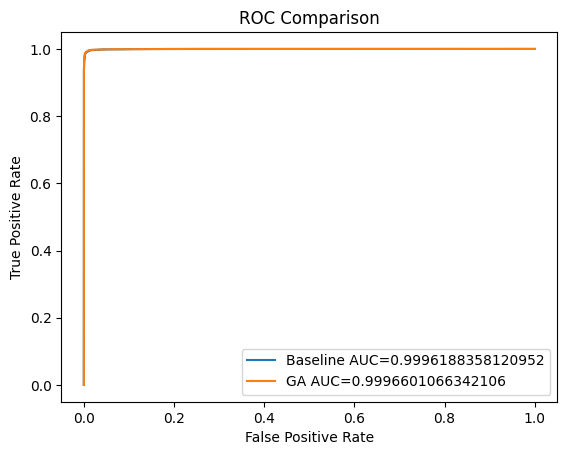

In [28]:
from sklearn.metrics import roc_curve, auc

# Baseline
base_probs = baseline_model.predict(X_test)
fpr_base, tpr_base, _ = roc_curve(y_test, base_probs)
auc_base = auc(fpr_base, tpr_base)

# GA model
ga_probs = final_model.predict(X_test)
fpr_ga, tpr_ga, _ = roc_curve(y_test, ga_probs)
auc_ga = auc(fpr_ga, tpr_ga)

# Plot
import matplotlib.pyplot as plt

plt.plot(fpr_base, tpr_base, label="Baseline AUC=" + str(auc_base))
plt.plot(fpr_ga, tpr_ga, label="GA AUC=" + str(auc_ga))

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.title("ROC Comparison")
plt.show()